# Linear Regression

In [25]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


### Data Preprocessing

In [26]:
df = pd.read_csv("linear_regression_dataset.csv")
df.head()

,AGE,FEMALE,LOS,RACE,TOTCHG,APRDRG
0,17,1,2,1.0,2660,560
1,17,0,2,1.0,1689,753
2,17,1,7,1.0,20060,930
3,17,1,1,1.0,736,758
4,17,1,1,1.0,1194,754


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AGE     500 non-null    int64  
 1   FEMALE  500 non-null    int64  
 2   LOS     500 non-null    int64  
 3   RACE    499 non-null    float64
 4   TOTCHG  500 non-null    int64  
 5   APRDRG  500 non-null    int64  
dtypes: float64(1), int64(5)
memory usage: 23.6 KB


In [28]:
df.describe()

,AGE,FEMALE,LOS,RACE,TOTCHG,APRDRG
count,500.000000,500.000000,500.000000,499.000000,500.000000,500.000000
mean,5.086000,0.512000,2.828000,1.078156,2774.388000,616.360000
std,6.949474,0.500357,3.363487,0.514746,3888.407367,178.316044
min,0.000000,0.000000,0.000000,1.000000,532.000000,21.000000
25%,0.000000,0.000000,2.000000,1.000000,1216.250000,640.000000
50%,0.000000,1.000000,2.000000,1.000000,1536.500000,640.000000
75%,13.000000,1.000000,3.000000,1.000000,2530.250000,751.000000
max,17.000000,1.000000,41.000000,6.000000,48388.000000,952.000000


In [29]:
df.isnull().sum()

AGE       0
FEMALE    0
LOS       0
RACE      1
TOTCHG    0
APRDRG    0
dtype: int64

In [30]:
# there is 1 null value in race which we fill with mode
df['RACE'].fillna(df['RACE'].mode()[0], inplace=True)

In [31]:
df.duplicated().sum()

np.int64(27)

In [32]:
# there are 27 duplicates which we remove
df = df.drop_duplicates()
df.duplicated().sum()


np.int64(0)

In [33]:
X = df[['AGE', 'FEMALE', 'LOS', 'RACE', 'APRDRG']].values
y = df['TOTCHG'].values

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [36]:
### Normalisation

In [37]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
# using z-score
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

In [47]:
import numpy as np

w = np.zeros(X_train.shape[1])
b = 0

lr = 0.01
epochs = 500

In [48]:
def compute_cost(X, y, w, b):
    m = len(y)
    preds = X @ w + b
    return (1/m) * np.sum((preds - y)**2)

In [49]:
def gradient_descent(X, y, w, b, lr):
    m = len(y)
    preds = X @ w + b
    
    dw = (2/m) * (X.T @ (preds - y))
    db = (2/m) * np.sum(preds - y)
    
    w -= lr * dw
    b -= lr * db
    
    return w, b

In [50]:
train_costs = []
test_costs = []

for epoch in range(epochs):
    w, b = gradient_descent(X_train, y_train, w, b, lr)
    
    train_cost = compute_cost(X_train, y_train, w, b)
    test_cost = compute_cost(X_test, y_test, w, b)
    
    train_costs.append(train_cost)
    test_costs.append(test_cost)
    
    print(f"Epoch {epoch+1}: Train={train_cost:.4f}, Test={test_cost:.4f}")

Epoch 1: Train=25240067.7594, Test=15859527.0151
Epoch 2: Train=24592240.5991, Test=15358469.2279
Epoch 3: Train=23969257.5855, Test=14876862.2883
Epoch 4: Train=23370154.0265, Test=14413947.0254
Epoch 5: Train=22794003.1856, Test=13968994.2924
Epoch 6: Train=22239914.7665, Test=13541303.7573
Epoch 7: Train=21707033.4594, Test=13130202.7443
Epoch 8: Train=21194537.5462, Test=12735045.1224
Epoch 9: Train=20701637.5623, Test=12355210.2392
Epoch 10: Train=20227575.0126, Test=11990101.8992
Epoch 11: Train=19771621.1392, Test=11639147.3832
Epoch 12: Train=19333075.7392, Test=11301796.5087
Epoch 13: Train=18911266.0302, Test=10977520.7277
Epoch 14: Train=18505545.5616, Test=10665812.2618
Epoch 15: Train=18115293.1695, Test=10366183.2732
Epoch 16: Train=17739911.9742, Test=10078165.0683
Epoch 17: Train=17378828.4181, Test=9801307.3344
Epoch 18: Train=17031491.3415, Test=9535177.4075
Epoch 19: Train=16697371.0965, Test=9279359.5698
Epoch 20: Train=16375958.6960, Test=9033454.3753
Epoch 21: Tra

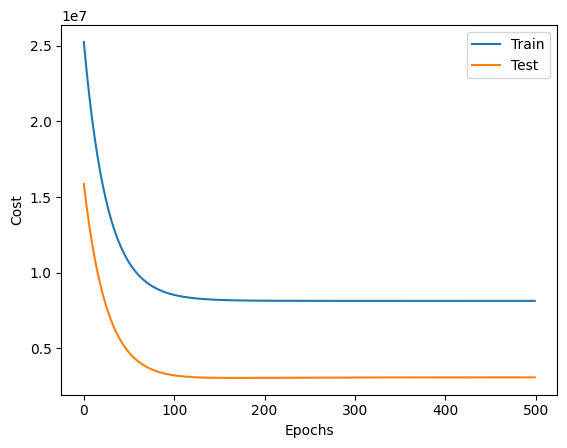

In [51]:
import matplotlib.pyplot as plt

plt.plot(train_costs, label="Train")
plt.plot(test_costs, label="Test")
plt.xlabel("Epochs")
plt.ylabel("Cost")
plt.legend()
plt.show()

In [52]:
import numpy as np

def r2_score(y_true, y_pred):
    ss_total = np.sum((y_true - np.mean(y_true))**2)
    ss_residual = np.sum((y_true - y_pred)**2)
    r2 = 1 - (ss_residual / ss_total)
    return r2

In [53]:
train_pred = X_train @ w + b
test_pred = X_test @ w + b

In [54]:
train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

print("Train R2:", round(train_r2, 4))
print("Test R2:", round(test_r2, 4))

Train R2: 0.5365
Test R2: 0.6488
